In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Annotated, Literal
from IPython.display import Image
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
import operator

In [5]:
llm = ChatOllama(
    model="qwen2.5-coder:7b",
    temperature=0
)

In [3]:
class TweetEvaluation(BaseModel):
    evaluation: Literal['approved', 'needs_imprvement']
    feedback : str = Field(..., description="feedback for the tweet.")

In [6]:
stracture_model = llm.with_structured_output(TweetEvaluation)

In [25]:
class TweerState(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal['approved', 'need_improvement']
    feedback : str
    iteration : int
    max_iteration : int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [26]:
def generate_tweet(state: TweerState):
    prompt = f"""
                Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

                Rules:
                - Do NOT use question-answer format.
                - Max 280 characters.
                - Use observational humor, irony, sarcasm, or cultural references.
                - Think in meme logic, punchlines, or relatable takes.
                - Use simple, day to day english
                """
    output = llm.invoke(prompt).content
    return {
        'tweet' : output
    }

def evaluation(state: TweerState):
    prompt = f"""
                Evaluate the following tweet:

                Tweet: "{state['tweet']}"

                Use the criteria below to evaluate the tweet:

                1. Originality – Is this fresh, or have you seen it a hundred times before?  
                2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
                3. Punchiness – Is it short, sharp, and scroll-stopping?  
                4. Virality Potential – Would people retweet or share it?  
                5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

                Auto-reject if:
                - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
                - It exceeds 280 characters
                - It reads like a traditional setup-punchline joke
                - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

                ### Respond ONLY in structured format:
                - evaluation: "approved" or "needs_improvement"  
                - feedback: One paragraph explaining the strengths and weaknesses 
            """
    output = stracture_model.invoke(prompt)
    return {
        'feedback' : output.feedback,
        'evaluation' : output.evaluation
    }

def optimize_tweet(state: TweerState):
    prompt = f"""
                Improve the tweet based on this feedback:
                "{state['feedback']}"

                Topic: "{state['topic']}"
                Original Tweet:
                {state['tweet']}

                Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
            """  
    response = llm.invoke(prompt).content  
    return {
        'tweet' : response,
        'interation' : state['iteration'] + 1
    }

def route_evaluation(state: TweerState):
    if state['feedback'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'need_improvement'
    

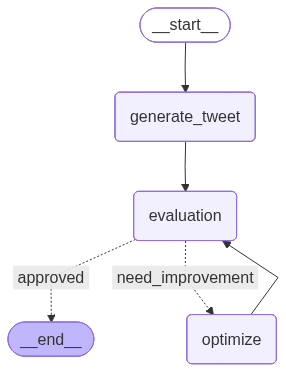

In [27]:
graph = StateGraph(TweerState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluation', evaluation)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluation')
graph.add_conditional_edges(
    'evaluation', route_evaluation,
    {
        'approved' : END,
        'need_improvement': 'optimize'
    }
)
graph.add_edge('optimize', 'evaluation')
workflow = graph.compile()

workflow
